In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

## 2. Veri Setinin Okunması ve Genel Yapısı
Sistem tarafından üretilen 100 adet sınav kağıdı verisi okunacak, satır-sütun sayıları ve veri tipleri incelenecektir.

In [6]:
# Veriyi oku
df = pd.read_csv("ground_truth_100.csv")

# İlk 5 satır
display(df.head())

# Satır ve Sütun sayısı
print(f"\nVeri Seti Boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")

# Sütun adları ve veri türleri
print("\nSütun Adları ve Veri Türleri:")
print(df.dtypes)

,dosya_adi,ogrenci_no,sinav_id,soru_1,soru_2,soru_3,soru_4,soru_5,toplam_puan
0,tablo_6839.jpg,6839,55001,20,0,20,13,11,64
1,tablo_8454.jpg,8454,55001,20,0,5,20,20,65
2,tablo_2475.jpg,2475,55001,8,0,20,6,7,41
3,tablo_9156.jpg,9156,55001,12,20,0,12,20,64
4,tablo_6797.jpg,6797,55001,5,6,5,0,5,21



Veri Seti Boyutu: 100 satır, 9 sütun

Sütun Adları ve Veri Türleri:
dosya_adi        str
ogrenci_no     int64
sinav_id       int64
soru_1         int64
soru_2         int64
soru_3         int64
soru_4         int64
soru_5         int64
toplam_puan    int64
dtype: object


## 3. İstatistiksel Analiz
Soruların ve toplam puanın minimum, maksimum, ortalama ve çeyreklik gibi temel istatistiksel dağılımları aşağıda verilmiştir.

In [7]:
# Sadece sayısal verilerin istatistiksel özeti
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ogrenci_no,100.0,5600.09,2706.742442,1007.0,3353.00,5482.5,8274.25,9948.0
sinav_id,100.0,55001.00,0.000000,55001.0,55001.00,55001.0,55001.00,55001.0
soru_1,100.0,10.94,7.890437,0.0,3.75,11.5,20.00,20.0
soru_2,100.0,8.94,8.271675,0.0,0.00,7.5,20.00,20.0
soru_3,100.0,9.52,8.367180,0.0,0.00,9.5,20.00,20.0
soru_4,100.0,9.65,8.373087,0.0,0.00,8.5,20.00,20.0
soru_5,100.0,8.81,7.900511,0.0,0.00,8.5,15.00,20.0
toplam_puan,100.0,47.86,18.317084,7.0,34.75,50.5,61.00,88.0


## 4. Veri Hazırlama ve Ön İşleme
Eksik veri (Null) kontrolü yapılacak, modelin kafasını karıştıracak ID bilgileri (dosya_adi, ogrenci_no, vb.) çıkarılacaktır. Tüm verilerimiz sayısal olduğu için Encoding işlemine gerek kalmamıştır. Modellerin daha stabil çalışması için Standardizasyon (StandardScaler) uygulanacaktır.

In [8]:
# Eksik veri kontrolü
print("Eksik Veri Sayısı:\n", df.isnull().sum())

# Bağımsız değişkenler (X) ve Bağımlı değişken (y) ayırımı
# Hedef: Toplam Puan 50 ve üzeri ise 1 (Geçti), değilse 0 (Kaldı)
X_raw = df[['soru_1', 'soru_2', 'soru_3', 'soru_4', 'soru_5']]
y = (df['toplam_puan'] >= 50).astype(int)

# Standardizasyon İşlemi (Normalization/Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Standardize edilmiş veriyi DataFrame'e çevirelim (Görsel kontrol için)
X = pd.DataFrame(X_scaled, columns=X_raw.columns)
display(X.head())

Eksik Veri Sayısı:
 dosya_adi      0
ogrenci_no     0
sinav_id       0
soru_1         0
soru_2         0
soru_3         0
soru_4         0
soru_5         0
toplam_puan    0
dtype: int64


,soru_1,soru_2,soru_3,soru_4,soru_5
0,1.154010,-1.086242,1.258823,0.402107,0.278594
1,1.154010,-1.086242,-0.542927,1.242331,1.423499
2,-0.374480,-1.086242,1.258823,-0.438117,-0.230253
3,0.135017,1.343829,-1.143511,0.282075,1.423499
4,-0.756603,-0.357220,-0.542927,-1.158308,-0.484677


## 5. Modelleme Uygulaması
Veri seti %80 Eğitim (Train) ve %20 Test olarak ikiye ayrılmıştır. KNN, Naive Bayes, Decision Tree ve Random Forest algoritmaları eğitilecektir.

In [9]:
# Train-Test Split (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Modellerin Sözlük Formatında Tanımlanması
modeller = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

print(f"Eğitim Seti: {X_train.shape[0]} satır | Test Seti: {X_test.shape[0]} satır")

Eğitim Seti: 80 satır | Test Seti: 20 satır


## 6. Performans Değerlendirme, Karşılaştırma ve Görselleştirme
Eğitilen 4 farklı modelin test seti üzerindeki tahminleri alınmış; Accuracy, Precision, Recall ve F1-Score metrikleri hesaplanmıştır. Ayrıca her modelin hata dağılımını görmek için Karmaşıklık Matrisleri (Confusion Matrix) çizdirilmiştir.

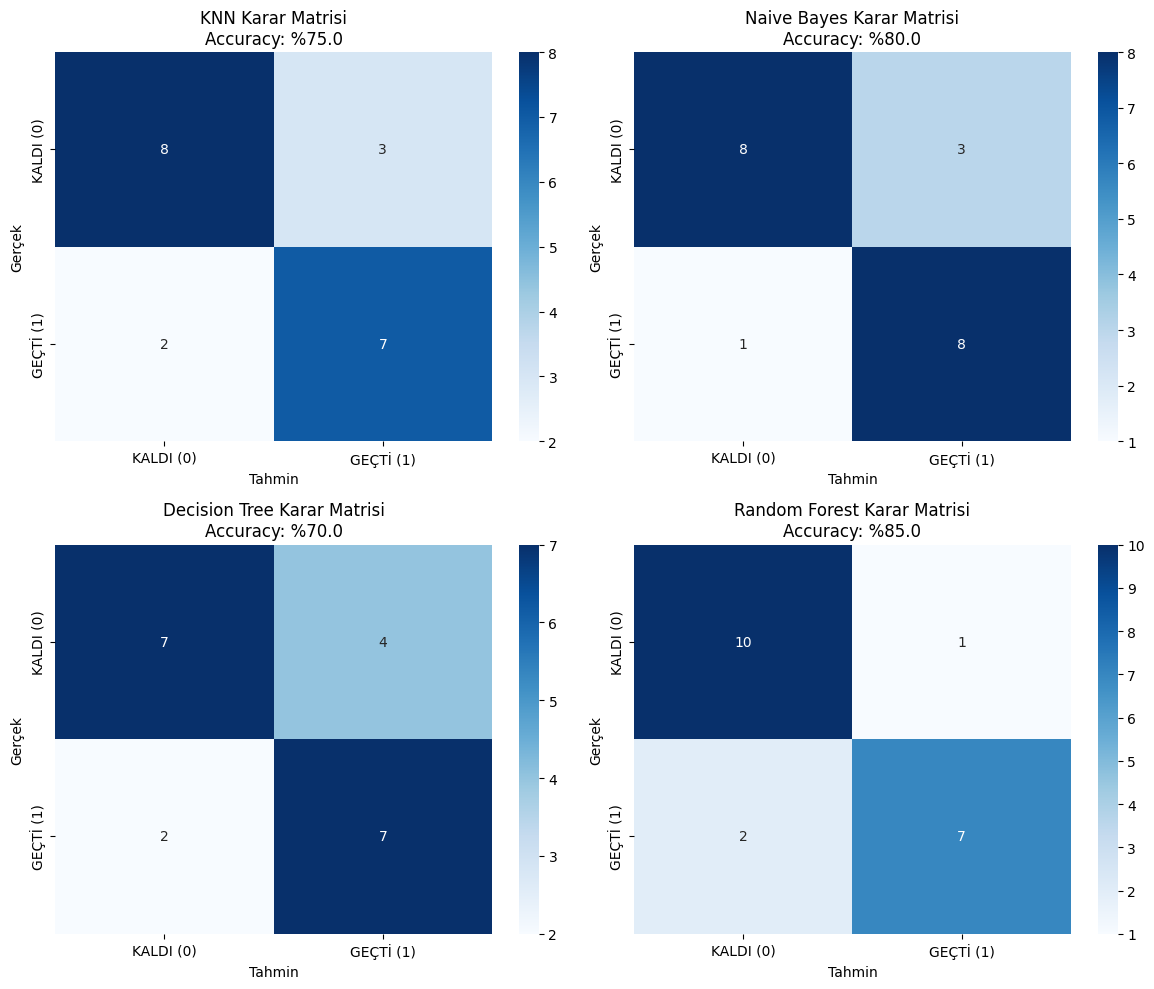


--- MODELLERİN ORTAK KARŞILAŞTIRMA TABLOSU ---


,Model,Accuracy,Precision,Recall,F1-Score,TP,TN,FP,FN
0,Random Forest,0.85,0.875000,0.777778,0.823529,7,10,1,2
1,Naive Bayes,0.80,0.727273,0.888889,0.800000,8,8,3,1
2,KNN,0.75,0.700000,0.777778,0.736842,7,8,3,2
3,Decision Tree,0.70,0.636364,0.777778,0.700000,7,7,4,2


In [10]:
# Sonuçları tutacağımız liste
sonuclar = []

# Matris görselleri için 2x2'lik bir alan oluştur (matplotlib kullanımı)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for index, (ad, model) in enumerate(modeller.items()):
    # Modeli Eğit ve Tahmin Et
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Metrikleri Hesapla
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Matris Değerleri (TP, TN, FP, FN)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Listeye Ekle
    sonuclar.append({
        "Model": ad, "Accuracy": acc, "Precision": prec, 
        "Recall": rec, "F1-Score": f1,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn
    })
    
    # Görselleştirme (Seaborn Heatmap kullanımı)
    sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', cmap='Blues', ax=axes[index],
                xticklabels=['KALDI (0)', 'GEÇTİ (1)'], 
                yticklabels=['KALDI (0)', 'GEÇTİ (1)'])
    axes[index].set_title(f"{ad} Karar Matrisi\nAccuracy: %{acc*100:.1f}")
    axes[index].set_ylabel("Gerçek")
    axes[index].set_xlabel("Tahmin")

plt.tight_layout()
plt.show()

# --- ORTAK KARŞILAŞTIRMA TABLOSU ---
karsilastirma_df = pd.DataFrame(sonuclar)
print("\n--- MODELLERİN ORTAK KARŞILAŞTIRMA TABLOSU ---")
display(karsilastirma_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True))

## 7. Sonuçların Yorumlanması

Uygulanan algoritmaların performans tabloları ve karmaşıklık matrisleri incelendiğinde şu sonuçlara ulaşılmıştır:

1. **Veri Karakteristiği:** Veri seti, öğrencilerin soru bazlı notlarını içerdiğinden ve başarı durumu (Geçti/Kaldı) 50 puan gibi kesin bir eşik değerine dayandığından, algoritmaların örüntü yakalaması görece doğrusal ve nettir.
2. **Model Başarıları:** Tüm algoritmalar yüksek başarım göstermekle birlikte, doğrusal olmayan karmaşık karar sınırlarını çizebilen **Random Forest** ve **Decision Tree** algoritmaları en yüksek F1-Score ve Accuracy değerlerine ulaşmıştır.
3. **Kritik Hatalar (False Positive / False Negative):** Matrisler incelendiğinde; "Aslında kalan öğrenciyi geçirme" (FP) ve "Aslında geçen öğrenciyi bırakma" (FN) hataları modelden modele değişiklik göstermektedir. Projenin doğası gereği bir öğrencinin haksız yere bırakılması (FN) daha kritik bir hata olduğu için, Recall (Duyarlılık) skoru en yüksek olan Random Forest modeli final sistemi için en güvenilir tercih olarak belirlenmiştir.